In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import sys
import os

os.chdir('..')
sys.path.append('src')

from load_clean import run_pipeline
from segmentation import (
    run_segmentation,
    assign_risk_segment,
    assign_value_segment,
    assign_behavior_segment
)
from lifetime_value import (
    run_ltv_analysis,
    ltv_summary,
    ltv_by_contract,
    ltv_by_value_segment,
    revenue_loss_projection
)

df = run_pipeline()
df = run_segmentation(df)

# Generate and save all charts
run_ltv_analysis(df)

[2026-03-27 21:59:43,631]: Loading data from: data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
[2026-03-27 21:59:44,044]: Raw data shape: (7043, 21)
[2026-03-27 21:59:44,045]: Cleaning data...
[2026-03-27 21:59:44,257]: Cleaned data shape: (7043, 26) | Churn rate: 26.54%
[2026-03-27 21:59:44,457]: Saved to: data\processed\telco_cleaned.csv
[2026-03-27 21:59:44,459]: Pipeline complete!
[2026-03-27 21:59:44,462]: Running segmentation...
[2026-03-27 21:59:44,507]: 
Risk Segment Distribution:
risk_segment
Low Risk         2167
Medium Risk      1634
High Risk        1624
Critical Risk    1618
[2026-03-27 21:59:44,537]: 
Churn Rate by Risk Segment:
risk_segment
Low Risk          3.41
Medium Risk      15.12
High Risk        34.24
Critical Risk    61.31
[2026-03-27 21:59:44,565]: 
Value Segment Distribution:
value_segment
Low Value     1762
Top Value     1761
Mid Value     1760
High Value    1760
[2026-03-27 21:59:44,577]: 
Churn Rate by Value Segment:
value_segment
Low Value     42.96
Mid Value 

{'avg_monthly': np.float64(64.76169246059918),
 'avg_tenure': np.float64(32.37114865824223),
 'avg_ltv': np.float64(2279.5813502768706),
 'median_ltv': np.float64(1393.6000000000001),
 'total_revenue': np.float64(16055091.45),
 'churned_ltv': np.float64(1531.6088282504013),
 'retained_ltv': np.float64(2549.770883262466),
 'revenue_lost': np.float64(2862576.9)}

In [2]:
df.groupby('risk_segment', observed=True).agg(
    customers  =('churn', 'count'),
    churned    =('churn', 'sum'),
    churn_rate =('churn', 'mean')
).assign(churn_rate=lambda x: x['churn_rate'].mul(100).round(2))

,customers,churned,churn_rate
risk_segment,,,
Low Risk,2167,74,3.41
Medium Risk,1634,247,15.12
High Risk,1624,556,34.24
Critical Risk,1618,992,61.31


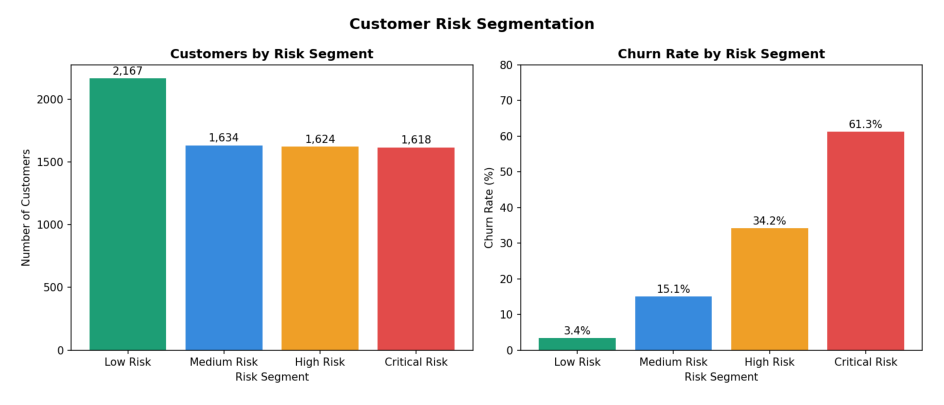

In [3]:
img = mpimg.imread('reports/figures/risk_segments.png')
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

In [4]:
ltv_by_value_segment(df)

[2026-03-27 22:06:33,582]: 
LTV by Value Segment:
               avg_ltv  avg_tenure  avg_monthly  churn_rate  customers
value_segment                                                         
Low Value       151.12        4.36        46.18        0.43       1762
Mid Value       859.59       24.34        50.67        0.26       1760
High Value     2394.91       39.53        68.62        0.23       1760
Top Value      5713.17       61.27        93.58        0.14       1761


,avg_ltv,avg_tenure,avg_monthly,churn_rate,customers
value_segment,,,,,
Low Value,151.12,4.36,46.18,0.43,1762
Mid Value,859.59,24.34,50.67,0.26,1760
High Value,2394.91,39.53,68.62,0.23,1760
Top Value,5713.17,61.27,93.58,0.14,1761


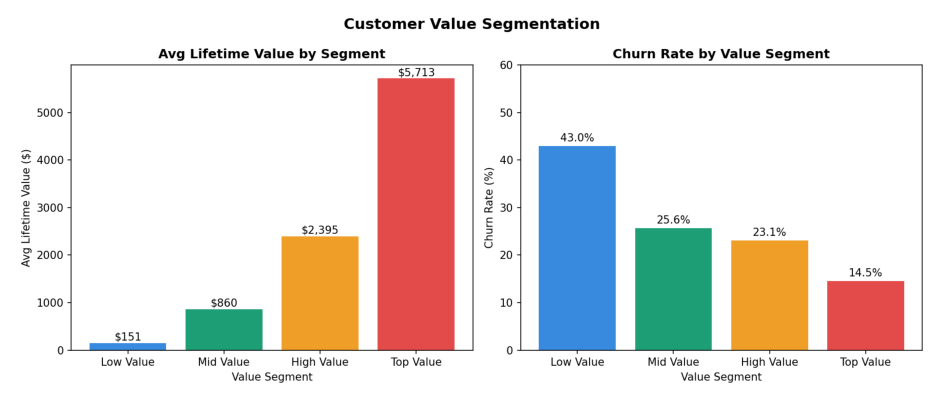

In [5]:
img = mpimg.imread('reports/figures/value_segments.png')
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

In [6]:
# Behavior segment distribution and churn rate
df.groupby('behavior_segment')['churn'].agg(
    customers='count',
    churned='sum',
    churn_rate='mean'
).assign(churn_rate=lambda x: x['churn_rate'].mul(100).round(2)) \
 .sort_values('churn_rate', ascending=False)

,customers,churned,churn_rate
behavior_segment,,,
New & Flexible,1994,1024,51.35
Established & Flexible,1881,631,33.55
Committed (1yr),1473,166,11.27
Loyal (2yr),1695,48,2.83


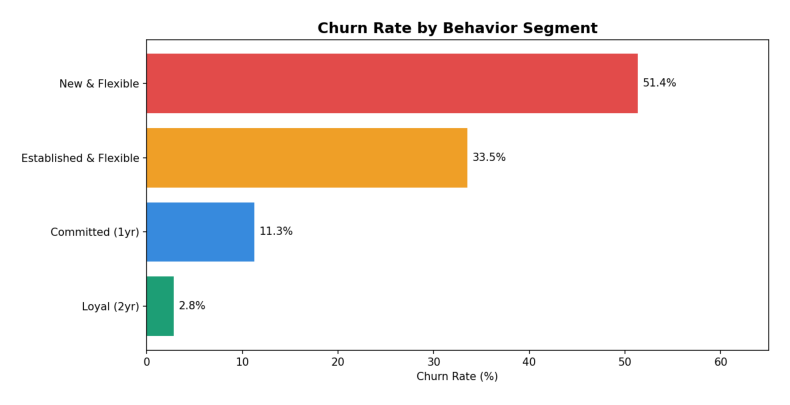

In [7]:
img = mpimg.imread('reports/figures/behavior_segments.png')
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

In [8]:
summary = ltv_summary(df)

[2026-03-27 22:12:49,548]: Avg Monthly Charge : $64.76
[2026-03-27 22:12:49,550]: Avg Tenure         : 32.4 months
[2026-03-27 22:12:49,551]: Avg LTV            : $2,279.58
[2026-03-27 22:12:49,552]: Median LTV         : $1,393.60
[2026-03-27 22:12:49,554]: Total Revenue      : $16,055,091.45
[2026-03-27 22:12:49,555]: Avg LTV Churned    : $1,531.61
[2026-03-27 22:12:49,557]: Avg LTV Retained   : $2,549.77
[2026-03-27 22:12:49,558]: Revenue Lost       : $2,862,576.90


In [9]:
ltv_by_contract(df)

[2026-03-27 22:12:58,366]: 
LTV by Contract:
                avg_ltv  median_ltv  total_revenue  customers
contract                                                     
Month-to-month  1370.12      686.25     5309195.75       3875
One year        3029.83     2665.70     4462938.05       1473
Two year        3706.76     3604.00     6282957.65       1695


,avg_ltv,median_ltv,total_revenue,customers
contract,,,,
Month-to-month,1370.12,686.25,5309195.75,3875
One year,3029.83,2665.70,4462938.05,1473
Two year,3706.76,3604.00,6282957.65,1695


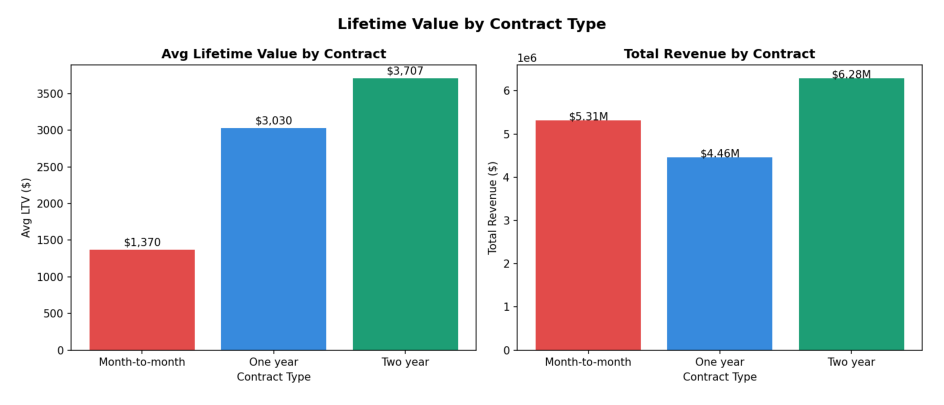

In [10]:
img = mpimg.imread('reports/figures/ltv_by_contract.png')
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

In [11]:
# Average LTV comparison
print(f"Avg LTV Retained : ${df[df['churn']==0]['lifetime_value'].mean():,.2f}")
print(f"Avg LTV Churned  : ${df[df['churn']==1]['lifetime_value'].mean():,.2f}")
print(f"LTV Gap          : ${df[df['churn']==0]['lifetime_value'].mean() - df[df['churn']==1]['lifetime_value'].mean():,.2f}")

Avg LTV Retained : $2,549.77
Avg LTV Churned  : $1,531.61
LTV Gap          : $1,018.16


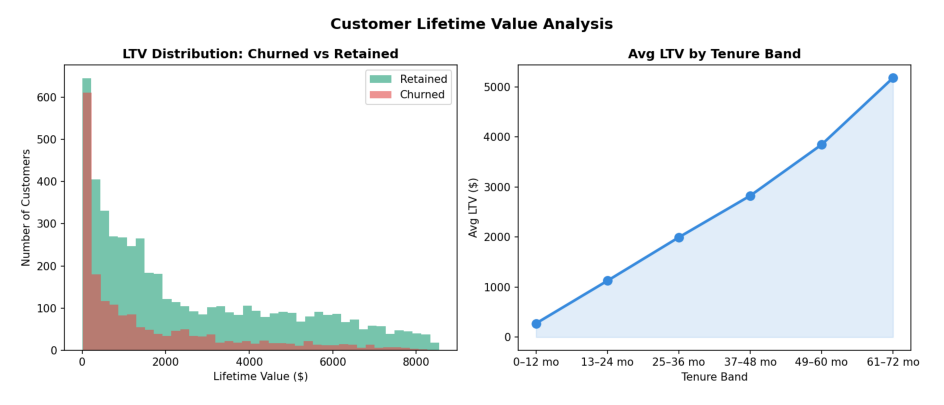

In [12]:
img = mpimg.imread('reports/figures/ltv_distribution.png')
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

In [13]:
revenue_loss_projection(df)

[2026-03-27 22:29:12,274]: 
Revenue Loss Projection:
    risk_segment  customers  churn_rate  avg_monthly  expected_churners  monthly_rev_at_risk  annual_rev_at_risk
0       Low Risk       2167    0.034149    45.631611                 74              3376.74            40520.88
1    Medium Risk       1634    0.151163    78.546665                247             19401.03           232812.36
2      High Risk       1624    0.342365    55.325493                556             30760.97           369131.64
3  Critical Risk       1618    0.613103    85.932664                992             85245.20          1022942.40


,risk_segment,customers,churn_rate,avg_monthly,expected_churners,monthly_rev_at_risk,annual_rev_at_risk
0,Low Risk,2167,0.034149,45.631611,74,3376.74,40520.88
1,Medium Risk,1634,0.151163,78.546665,247,19401.03,232812.36
2,High Risk,1624,0.342365,55.325493,556,30760.97,369131.64
3,Critical Risk,1618,0.613103,85.932664,992,85245.20,1022942.40


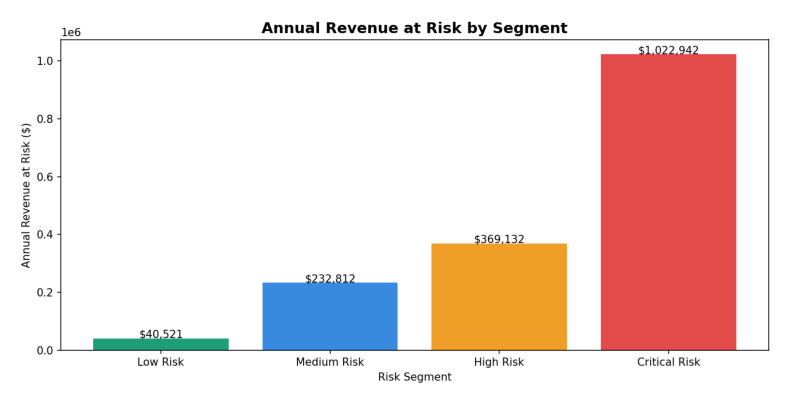

In [14]:
img = mpimg.imread('reports/figures/revenue_at_risk.png')
plt.figure(figsize=(10, 5))
plt.imshow(img)
plt.axis('off')
plt.show()